# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Employee Attrition & HR Dataset](https://www.kaggle.com/datasets/uditjain13/employee-attrition-and-hr-analytics-2026/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('employee_attrition_hr_2026.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
0,1001,37,Male,Divorced,Masters,Engineering,Engineering Manager,3,7365,0,14.1,7.3,15.9,1.5,3,Remote,5,2.4,6,17,9.4,1.0,9.7,7.7,3,8.3,True,4.8,No
1,1002,24,Female,Married,Bachelors,Finance,Finance Manager,2,4746,2,7.9,3.0,4.0,2.5,3,Onsite,7,4.1,5,21,4.2,1.9,5.4,7.8,3,8.0,True,2.9,Yes
2,1003,24,Female,Single,Bachelors,Marketing,Marketing Specialist,1,2740,2,12.8,3.0,4.0,1.3,3,Hybrid,28,3.3,7,22,7.5,5.3,6.5,7.0,4,9.5,True,7.2,No
3,1004,44,Male,Single,Bachelors,Sales,Sales Manager,4,7334,1,12.8,9.2,12.5,0.5,0,Hybrid,19,12.0,21,21,8.7,4.3,7.3,3.5,4,7.9,False,5.2,No
4,1005,37,Female,Divorced,Bachelors,Sales,Sales Development Rep,3,9096,0,10.6,4.9,10.5,0.2,0,Hybrid,36,4.9,20,20,7.5,2.3,7.0,7.2,4,8.5,False,6.4,No


## last Five row

In [4]:
df.tail()

,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,work_mode,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,uses_ai_tools_at_work,perceived_ai_job_risk,attrition
4995,5996,40,Male,Married,Masters,Engineering,Engineering Manager,4,13662,1,9.5,8.4,16.4,1.3,2,Onsite,43,12.3,4,14,5.4,6.0,6.5,4.4,4,7.5,True,4.6,Yes
4996,5997,45,Male,Single,Bachelors,Sales,Account Executive,3,7353,3,9.6,5.0,12.9,1.9,5,Onsite,45,4.0,18,21,4.5,5.6,5.4,5.8,4,9.0,True,4.3,No
4997,5998,33,Male,Married,Masters,Research & Development,Product Researcher,1,3746,2,7.3,2.3,11.5,2.3,3,Remote,0,3.0,5,15,6.5,2.0,5.0,8.5,3,7.2,False,4.8,No
4998,5999,36,Female,Married,Masters,Finance,Finance Manager,4,9430,1,10.2,9.9,15.3,6.2,1,Remote,0,6.8,8,31,5.7,2.4,5.9,8.2,3,6.8,False,4.5,No
4999,6000,55,Male,Married,Bachelors,Customer Support,Support Specialist,4,6583,2,13.3,10.5,17.0,0.4,2,Onsite,44,21.6,8,10,6.4,8.0,5.3,5.4,3,10.0,True,9.8,Yes


## Shape of our dataset

In [5]:
df.shape

(5000, 29)

## List out all columns

In [6]:
df.columns

Index(['employee_id', 'age', 'gender', 'marital_status', 'education_level',
       'department', 'job_role', 'job_level', 'monthly_income',
       'stock_option_level', 'salary_hike_pct', 'years_at_company',
       'total_working_years', 'years_since_promotion', 'num_prior_companies',
       'work_mode', 'commute_minutes', 'overtime_hours_per_week',
       'business_travel_days_per_year', 'training_hours',
       'manager_support_score', 'burnout_score', 'engagement_score',
       'work_life_balance_score', 'performance_rating', 'last_review_score',
       'uses_ai_tools_at_work', 'perceived_ai_job_risk', 'attrition'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

employee_id                        int64
age                                int64
gender                            object
marital_status                    object
education_level                   object
department                        object
job_role                          object
job_level                          int64
monthly_income                     int64
stock_option_level                 int64
salary_hike_pct                  float64
years_at_company                 float64
total_working_years              float64
years_since_promotion            float64
num_prior_companies                int64
work_mode                         object
commute_minutes                    int64
overtime_hours_per_week          float64
business_travel_days_per_year      int64
training_hours                     int64
manager_support_score            float64
burnout_score                    float64
engagement_score                 float64
work_life_balance_score          float64
performance_rati

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   employee_id                    5000 non-null   int64  
 1   age                            5000 non-null   int64  
 2   gender                         5000 non-null   object 
 3   marital_status                 5000 non-null   object 
 4   education_level                5000 non-null   object 
 5   department                     5000 non-null   object 
 6   job_role                       5000 non-null   object 
 7   job_level                      5000 non-null   int64  
 8   monthly_income                 5000 non-null   int64  
 9   stock_option_level             5000 non-null   int64  
 10  salary_hike_pct                5000 non-null   float64
 11  years_at_company               5000 non-null   float64
 12  total_working_years            5000 non-null   f

## Check Null Value

In [9]:
df.isnull().sum()

employee_id                      0
age                              0
gender                           0
marital_status                   0
education_level                  0
department                       0
job_role                         0
job_level                        0
monthly_income                   0
stock_option_level               0
salary_hike_pct                  0
years_at_company                 0
total_working_years              0
years_since_promotion            0
num_prior_companies              0
work_mode                        0
commute_minutes                  0
overtime_hours_per_week          0
business_travel_days_per_year    0
training_hours                   0
manager_support_score            0
burnout_score                    0
engagement_score                 0
work_life_balance_score          0
performance_rating               0
last_review_score                0
uses_ai_tools_at_work            0
perceived_ai_job_risk            0
attrition           

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,employee_id,age,job_level,monthly_income,stock_option_level,salary_hike_pct,years_at_company,total_working_years,years_since_promotion,num_prior_companies,commute_minutes,overtime_hours_per_week,business_travel_days_per_year,training_hours,manager_support_score,burnout_score,engagement_score,work_life_balance_score,performance_rating,last_review_score,perceived_ai_job_risk
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,37.119800,2.925200,6990.71980,1.089800,11.518200,6.724620,11.69926,1.971900,1.805200,31.160200,6.828220,10.819000,22.598800,6.613500,4.033360,6.507980,6.130360,3.615800,8.330920,4.856720
std,1443.520003,8.234161,1.201621,2701.89936,0.936542,3.408021,3.500219,4.99587,1.628239,1.345665,19.435073,4.470515,8.092227,11.006019,1.836603,1.540043,1.497677,1.288287,0.661421,1.149132,1.832426
min,1001.000000,21.000000,1.000000,1500.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.800000,1.000000
25%,2250.750000,31.000000,2.000000,4971.00000,0.000000,9.300000,4.275000,8.30000,0.800000,1.000000,14.000000,3.600000,5.000000,15.000000,5.400000,2.900000,5.500000,5.300000,3.000000,7.500000,3.600000
50%,3500.500000,37.000000,3.000000,6569.00000,1.000000,11.600000,6.800000,11.90000,1.600000,2.000000,33.000000,5.900000,7.000000,22.000000,6.700000,4.000000,6.500000,6.200000,4.000000,8.400000,4.900000
75%,4750.250000,43.000000,4.000000,8604.25000,2.000000,13.800000,9.200000,15.10000,2.800000,3.000000,46.000000,9.000000,18.000000,30.000000,7.900000,5.000000,7.600000,7.000000,4.000000,9.200000,6.100000
max,6000.000000,64.000000,5.000000,21609.00000,3.000000,22.600000,18.100000,30.40000,11.100000,8.000000,92.000000,34.900000,38.000000,67.000000,10.000000,10.000000,10.000000,9.900000,5.000000,10.000000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

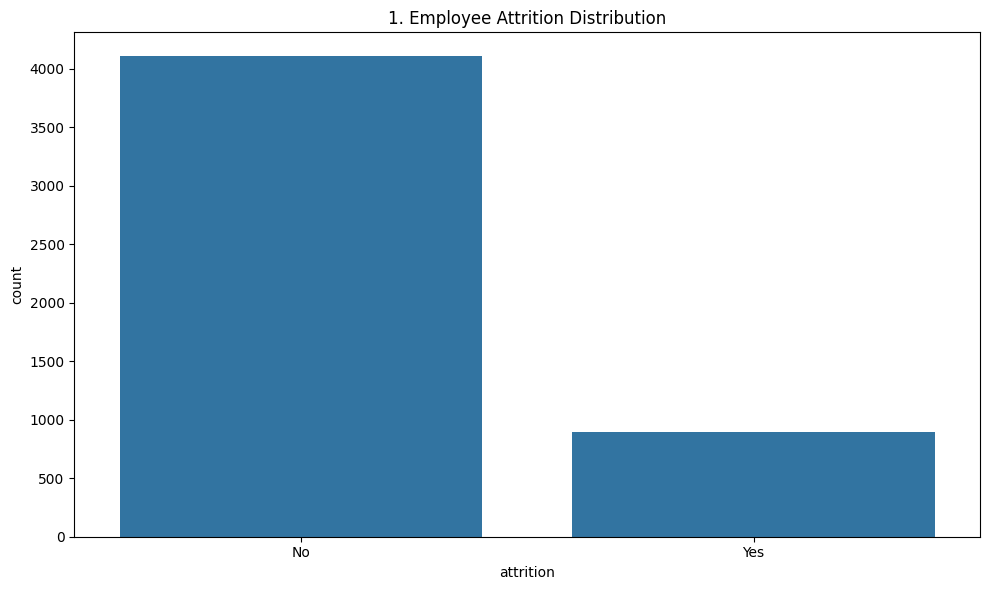

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='attrition')
plt.title(f'{plot_no}. Employee Attrition Distribution')
show_fig()
plot_no += 1

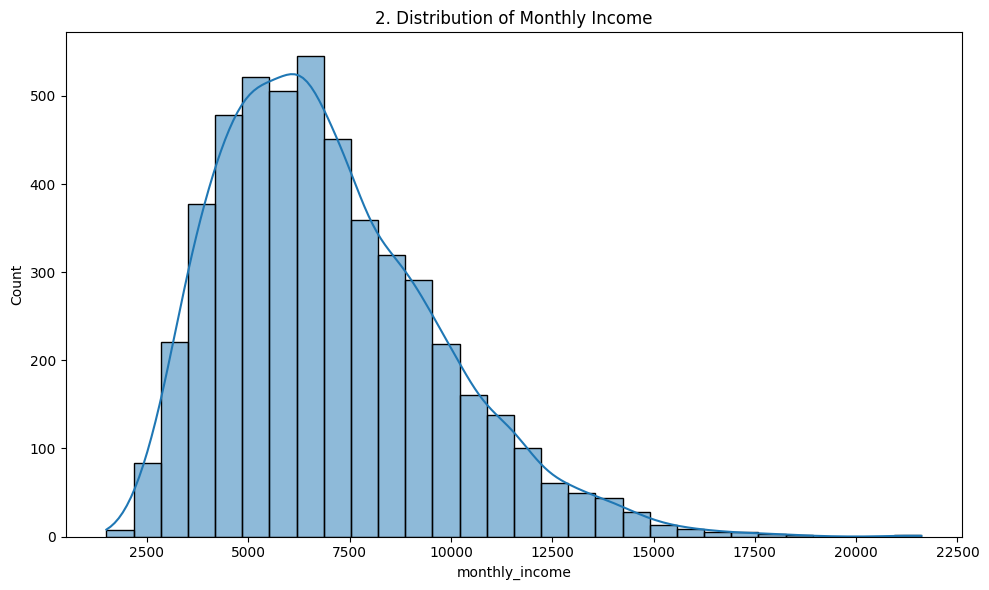

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='monthly_income', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Monthly Income')
show_fig()
plot_no += 1

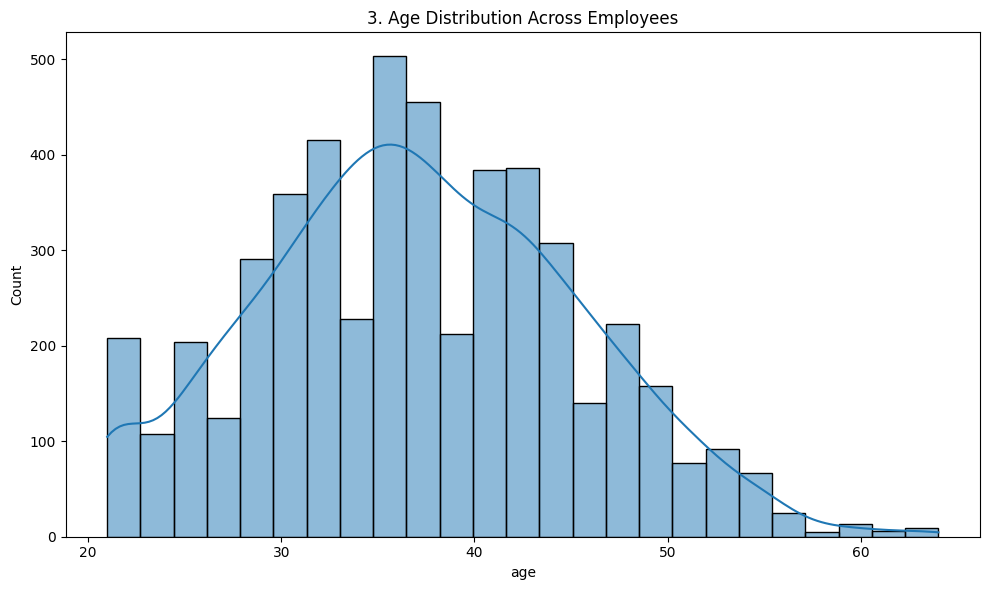

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', bins=25, kde=True)
plt.title(f'{plot_no}. Age Distribution Across Employees')
show_fig()
plot_no += 1

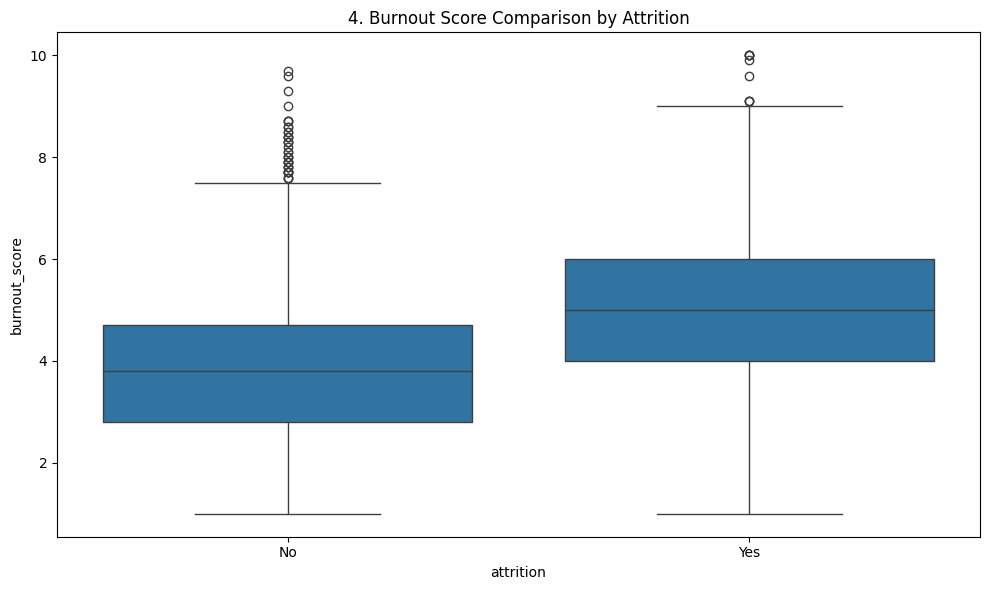

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='attrition', y='burnout_score')
plt.title(f'{plot_no}. Burnout Score Comparison by Attrition')
show_fig()
plot_no += 1

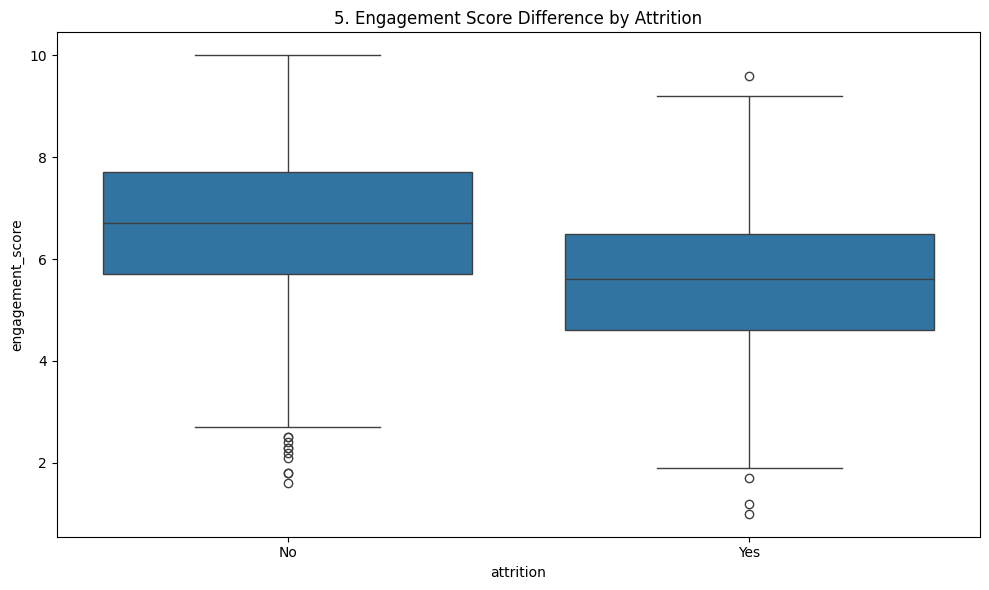

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='attrition', y='engagement_score')
plt.title(f'{plot_no}. Engagement Score Difference by Attrition')
show_fig()
plot_no += 1

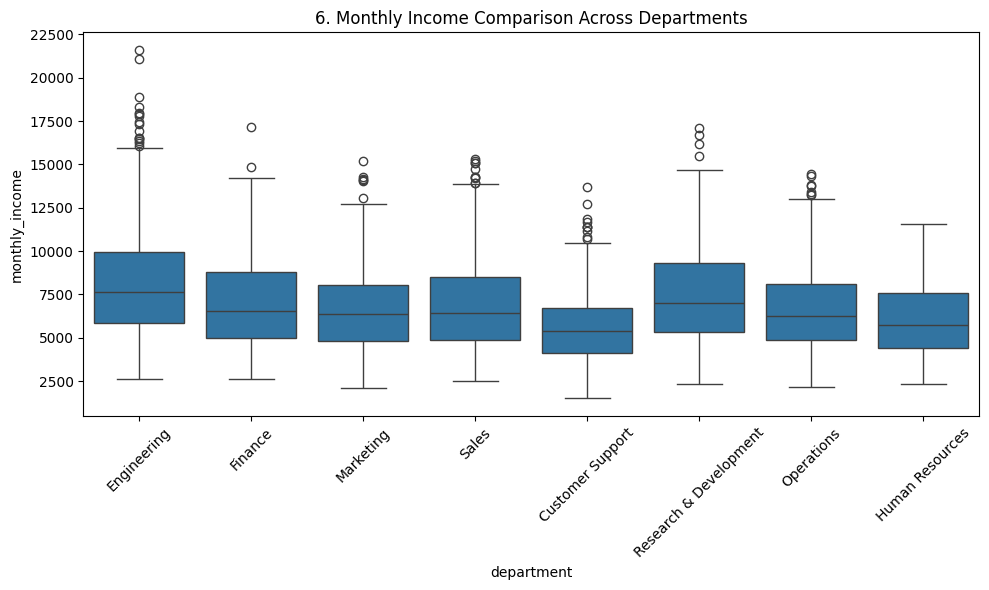

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='department', y='monthly_income')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Monthly Income Comparison Across Departments')
show_fig()
plot_no += 1

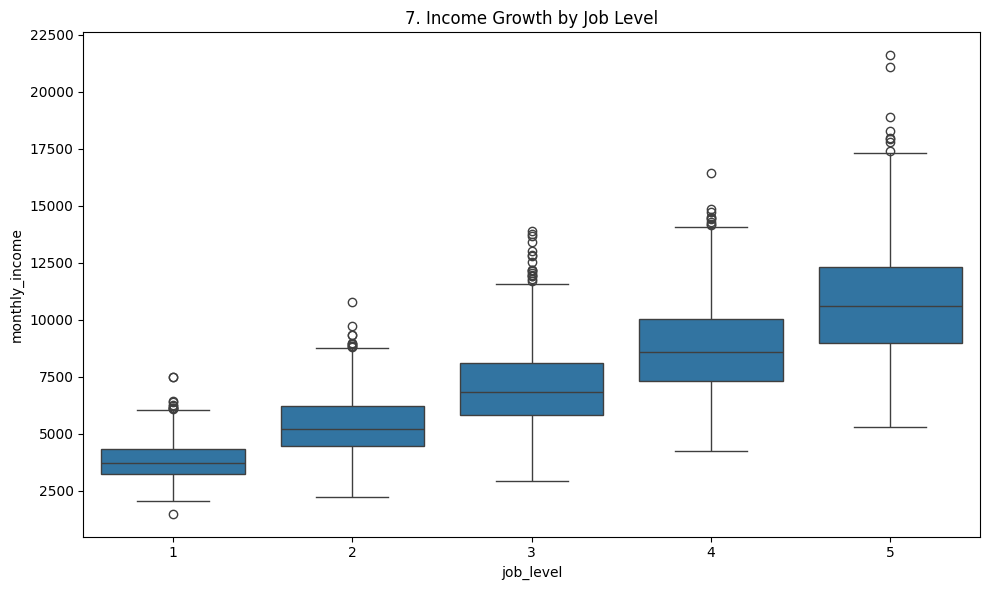

In [19]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='job_level', y='monthly_income')
plt.title(f'{plot_no}. Income Growth by Job Level')
show_fig()
plot_no += 1

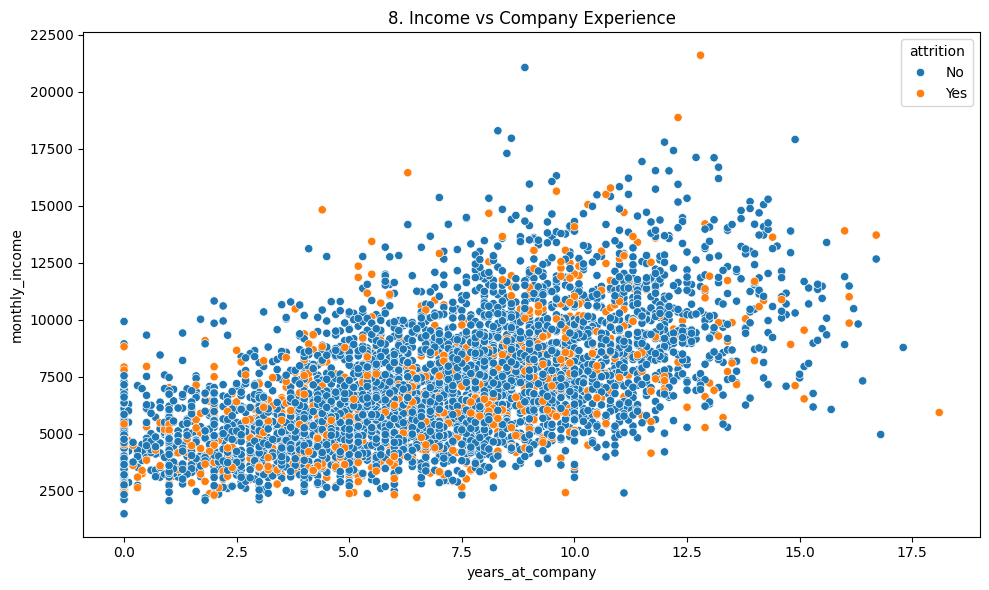

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_at_company', y='monthly_income', hue='attrition')
plt.title(f'{plot_no}. Income vs Company Experience')
show_fig()
plot_no += 1

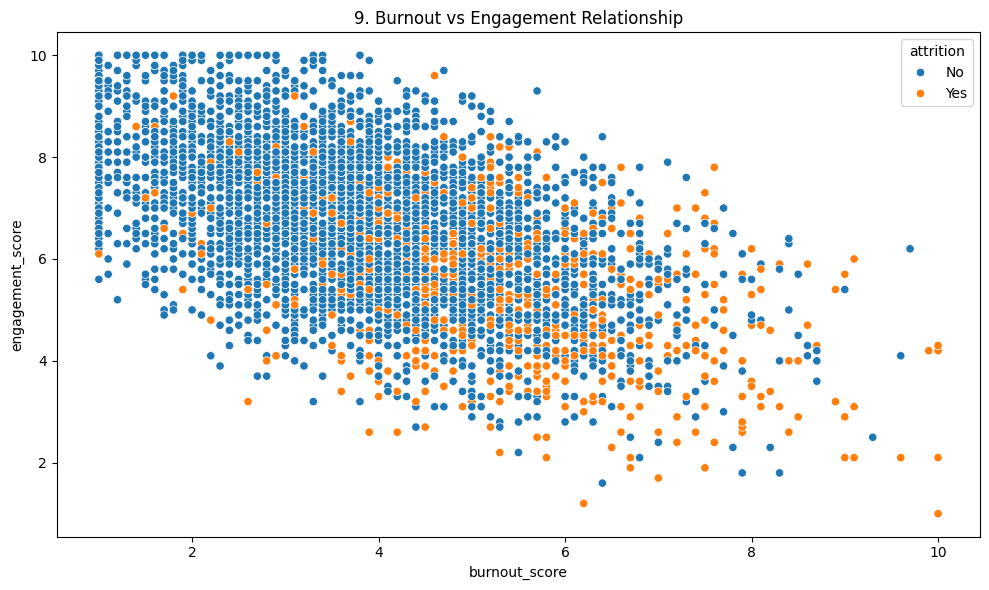

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='burnout_score', y='engagement_score', hue='attrition')
plt.title(f'{plot_no}. Burnout vs Engagement Relationship')
show_fig()
plot_no += 1

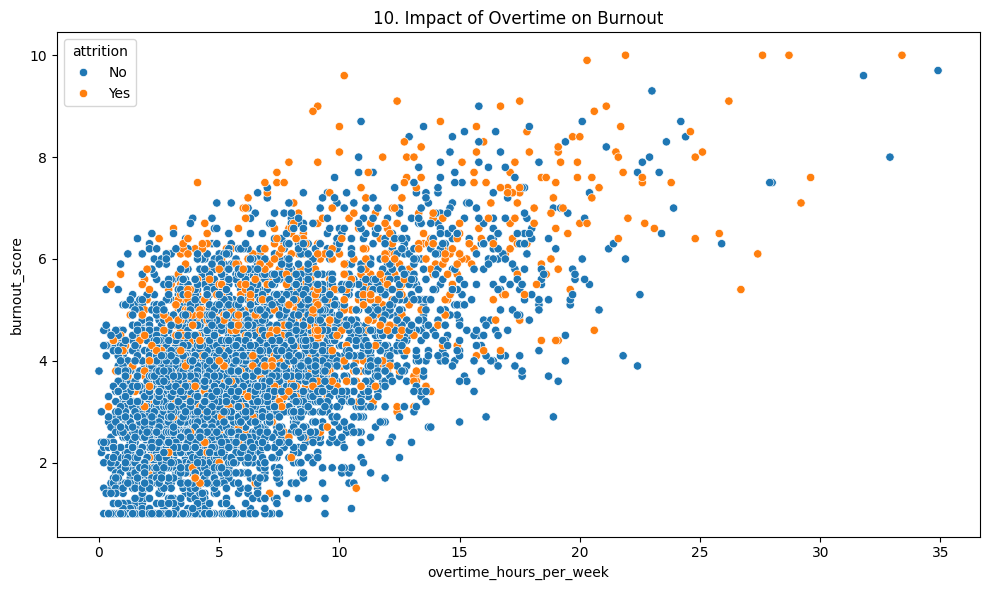

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='overtime_hours_per_week', y='burnout_score', hue='attrition')
plt.title(f'{plot_no}. Impact of Overtime on Burnout')
show_fig()
plot_no += 1

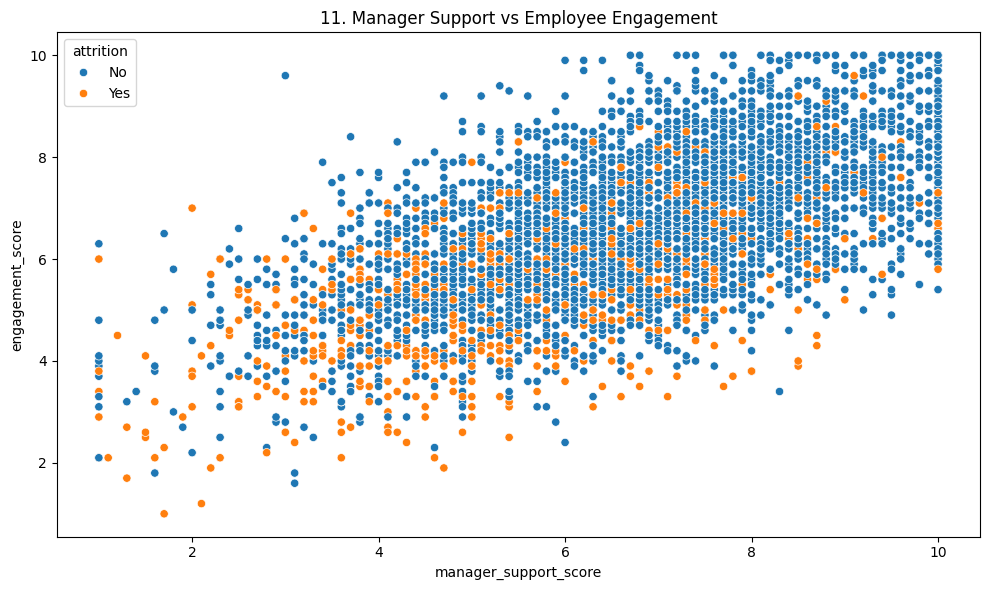

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='manager_support_score', y='engagement_score', hue='attrition')
plt.title(f'{plot_no}. Manager Support vs Employee Engagement')
show_fig()
plot_no += 1

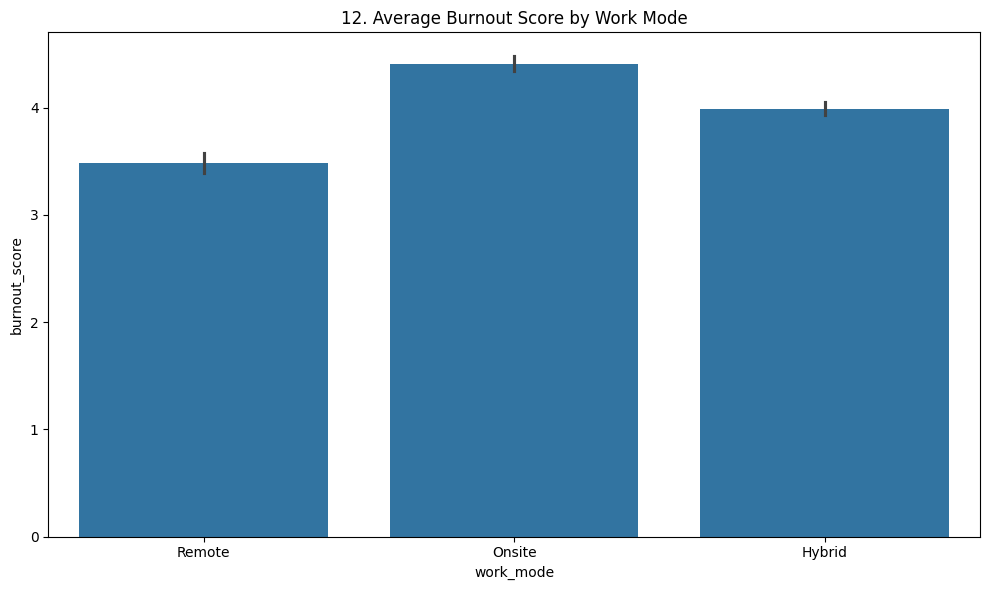

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='work_mode', y='burnout_score')
plt.title(f'{plot_no}. Average Burnout Score by Work Mode')
show_fig()
plot_no += 1

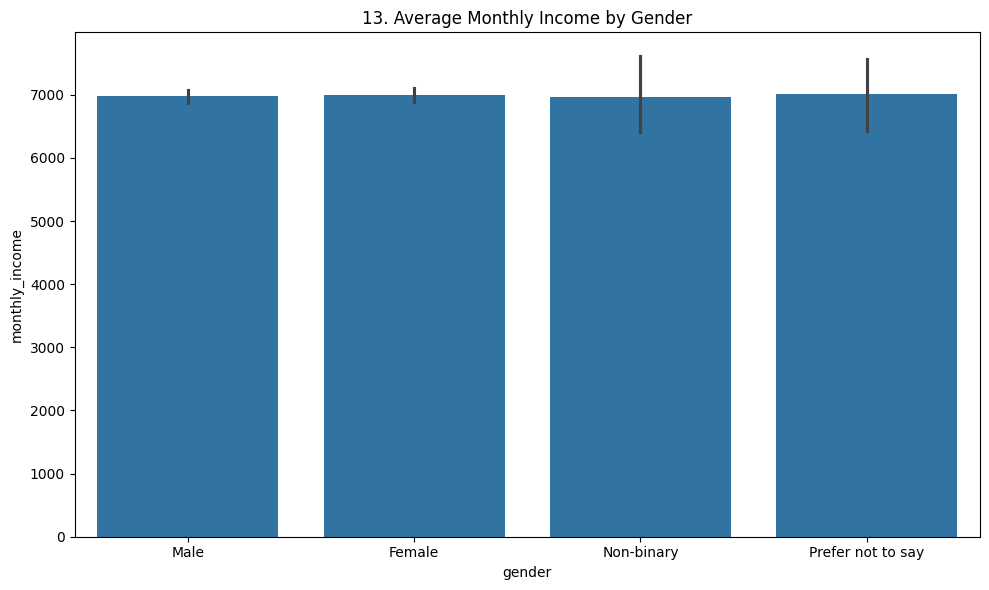

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='gender', y='monthly_income')
plt.title(f'{plot_no}. Average Monthly Income by Gender')
show_fig()
plot_no += 1

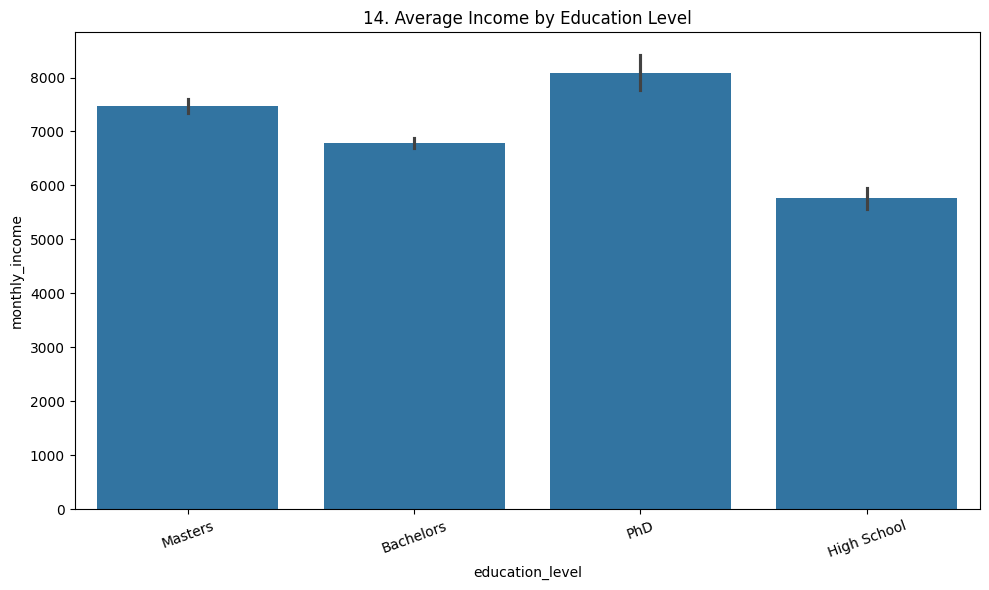

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='education_level', y='monthly_income')
plt.xticks(rotation=20)
plt.title(f'{plot_no}. Average Income by Education Level')
show_fig()
plot_no += 1

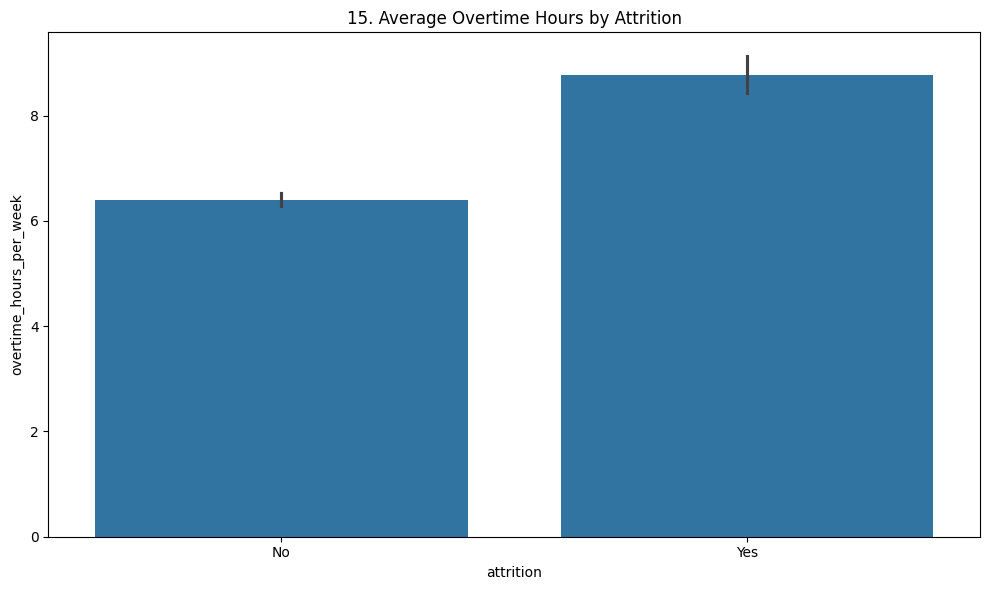

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='attrition', y='overtime_hours_per_week')
plt.title(f'{plot_no}. Average Overtime Hours by Attrition')
show_fig()
plot_no += 1

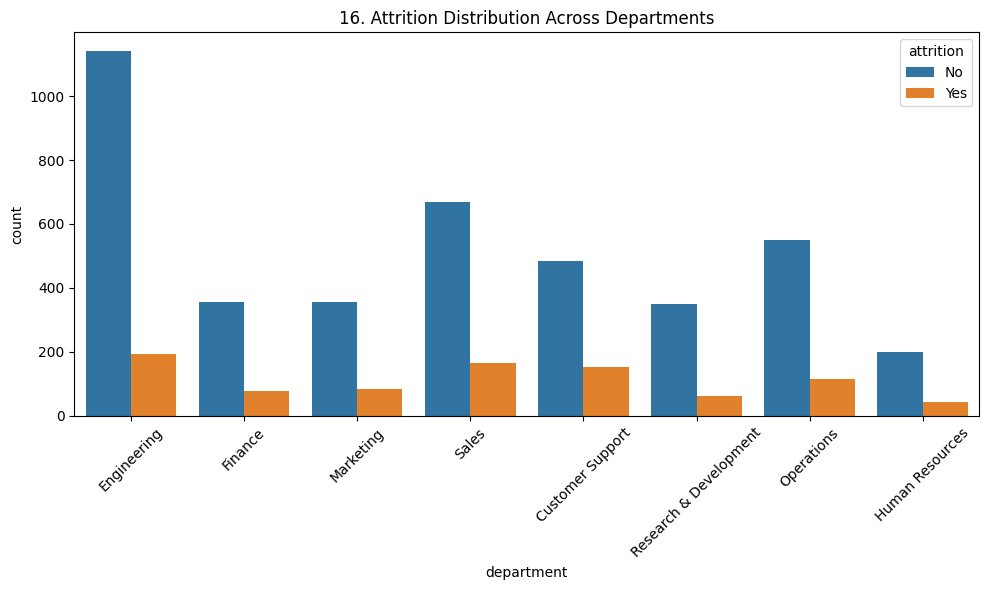

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='department', hue='attrition')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Attrition Distribution Across Departments')
show_fig()
plot_no += 1

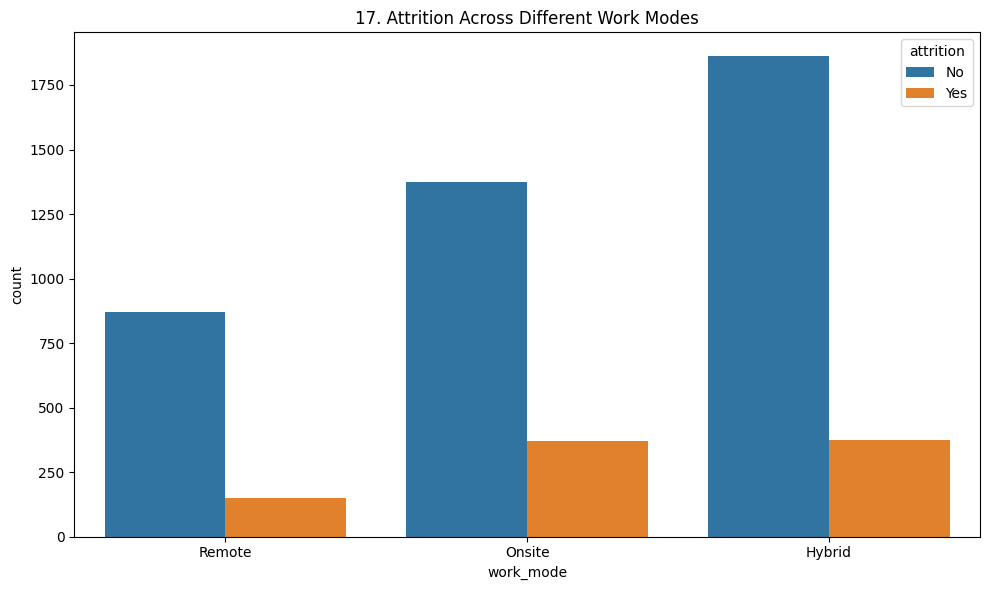

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='work_mode', hue='attrition')
plt.title(f'{plot_no}. Attrition Across Different Work Modes')
show_fig()
plot_no += 1

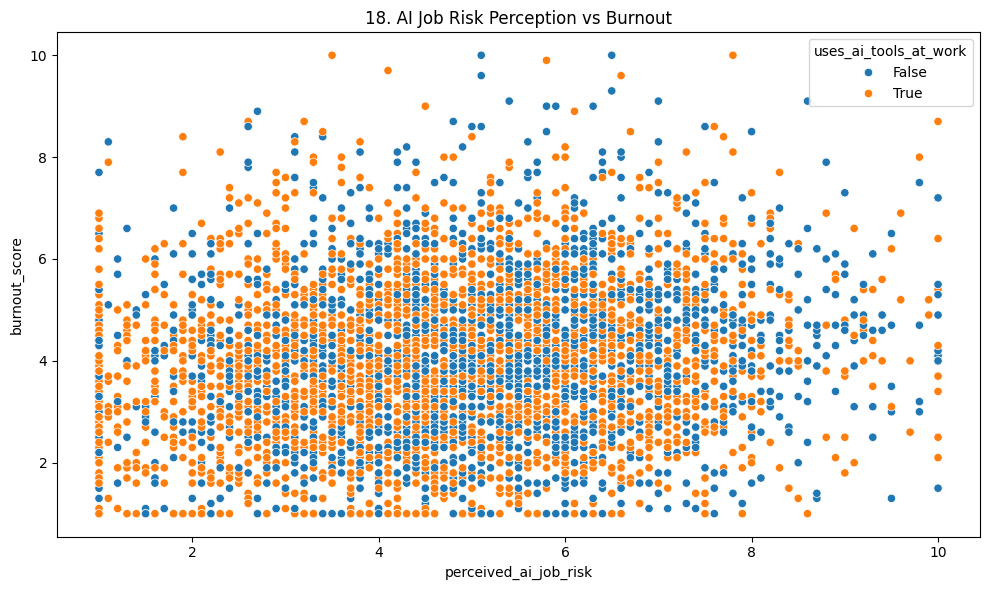

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='perceived_ai_job_risk', y='burnout_score', hue='uses_ai_tools_at_work')
plt.title(f'{plot_no}. AI Job Risk Perception vs Burnout')
show_fig()
plot_no += 1

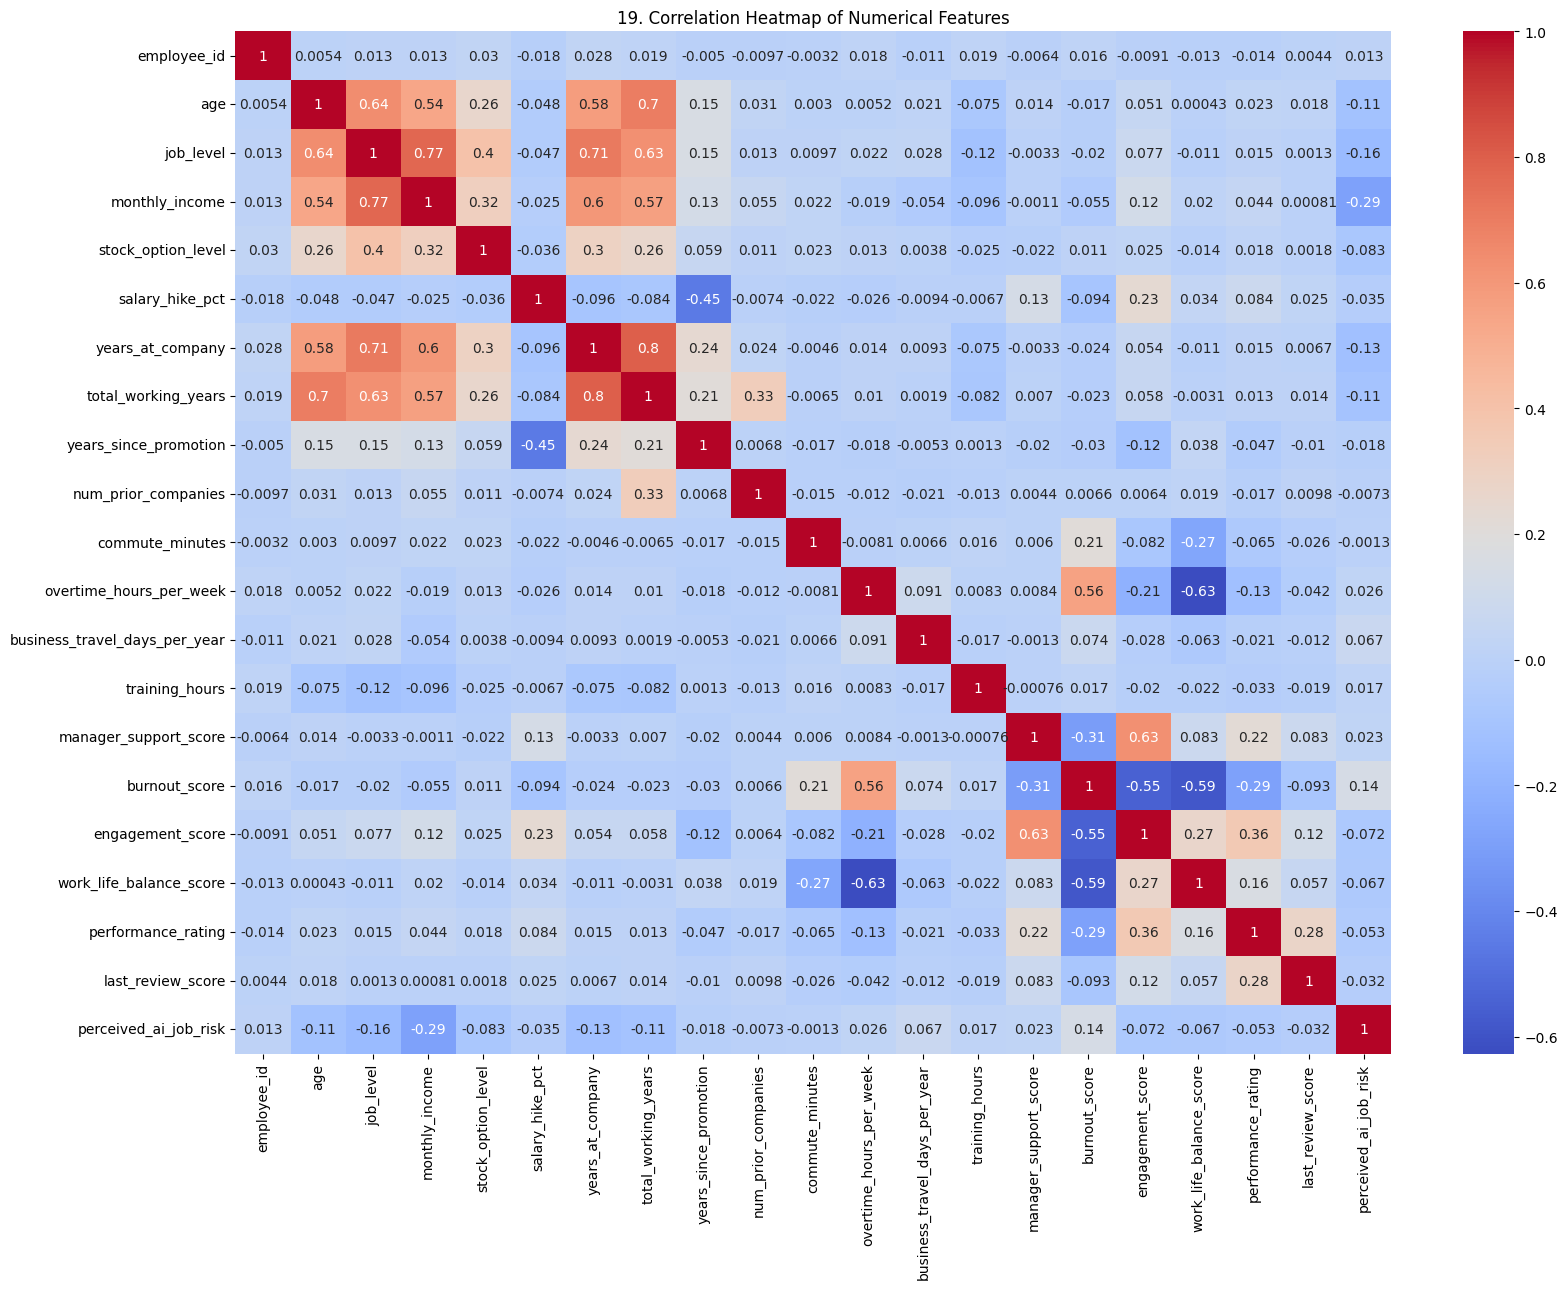

In [31]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(17, 13))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create a copy of the dataset

In [32]:
data = df.copy()

## Enter your target column here

In [33]:
target_column = "department"

## Encode the target column if it is categorical

In [34]:
if data[target_column].dtype == "object" or str(data[target_column].dtype) == "bool":
    target_encoder = LabelEncoder()
    data[target_column] = target_encoder.fit_transform(data[target_column])

## Separate features and target

In [35]:
X = data.drop(columns=[target_column])
y = data[target_column]

## Find categorical and numerical columns

In [36]:
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
numerical_cols = X.select_dtypes(include=np.number).columns

## Fill missing values in numerical columns

In [37]:
num_imputer = SimpleImputer(strategy="median")
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

## Fill missing values in categorical columns

In [38]:
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

## Encode categorical features

In [39]:
for col in categorical_cols:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str))

## Split the dataset

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Scale numerical features

In [41]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## Train the Support Vector Machine model

In [42]:
model = SVC(kernel="rbf", random_state=42)
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Predict on the test set

In [43]:
y_pred = model.predict(X_test)

## Print model accuracy

In [44]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score : {accuracy:.4f}")

Accuracy Score : 0.7390


## Display confusion matrix

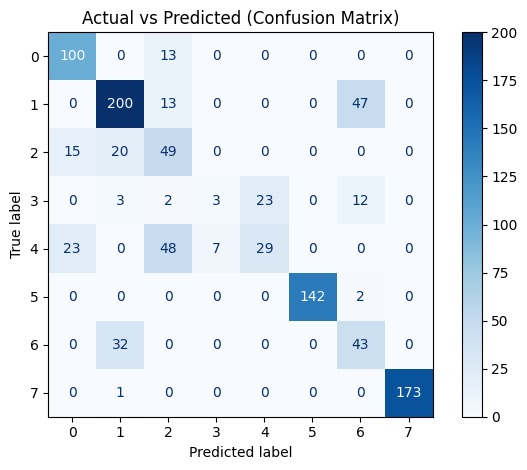

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()